In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import moocore

In [14]:
df_memory = pd.read_csv("memory_results.csv")
df_memory = df_memory[df_memory["seed"] == 888]
df_memory.drop_duplicates(inplace=True)
df_memory

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 23,Unnamed: 24,flash_code,Unnamed: 26,Unnamed: 27,Unnamed: 28,total_size,seed,idx,dataset
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,605916.0,256.0,2331466.0,2427857.0,888,10441,cifar10
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,536252.0,256.0,2261802.0,2358193.0,888,10401,cifar10
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,1112668.0,256.0,2838218.0,2934609.0,888,10321,cifar10
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,265196.0,256.0,1990746.0,2087137.0,888,10481,cifar10
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,604732.0,256.0,2330282.0,2426673.0,888,10511,cifar10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14815,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,397564.0,256.0,2123114.0,2219505.0,888,253,cifar10
14816,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,544012.0,256.0,2269562.0,2365953.0,888,2583,cifar10
14817,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,374268.0,256.0,2099818.0,2196209.0,888,2742,cifar10
14818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1028.0,15356.0,...,0.243443,258561.0,1725294.0,552716.0,256.0,2278266.0,2374657.0,888,2752,cifar10


In [15]:
df_accuracy = pd.read_csv("result.csv")
df_accuracy = df_accuracy[df_accuracy["seed"] == 888]
df_accuracy.drop_duplicates(inplace=True)
df_accuracy

,idx,seed,dataset,fp32_acc,esp_acc
163,763,888,cifar10,75.55,18.68
167,931,888,cifar10,62.55,15.64
171,1296,888,cifar10,73.62,30.27
185,379,888,cifar10,87.19,84.66
201,113,888,cifar10,87.09,71.13
...,...,...,...,...,...
39296,14896,888,cifar10,91.80,91.75
39406,4461,888,cifar10,87.45,82.22
40585,5144,888,cifar10,93.07,92.52
41133,7045,888,cifar10,89.85,89.40


In [31]:
df_hwnas = pd.read_csv("../all_hwnas.csv", index_col=0)
df_hwnas.columns

Index(['edgegpu_latency', 'edgegpu_energy', 'raspi4_latency',
       'edgetpu_latency', 'pixel3_latency', 'eyeriss_latency',
       'eyeriss_energy', 'eyeriss_arithmetic_intensity', 'fpga_latency',
       'fpga_energy', 'average_hw_metric', 'arch_index', 'seed', 'flop',
       'test_acc', 'dataset', 'arch_0', 'arch_1', 'arch_2', 'arch_3', 'arch_4',
       'arch_5'],
      dtype='str')

In [33]:
df_merged = df_accuracy.merge(df_memory).merge(df_hwnas, left_on = ["seed", "idx", "dataset"], right_on = ["seed", "arch_index", "dataset"])
df_merged

,idx,seed,dataset,fp32_acc,esp_acc,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,...,average_hw_metric,arch_index,flop,test_acc,arch_0,arch_1,arch_2,arch_3,arch_4,arch_5
0,763,888,cifar10,75.55,18.68,0.0,0.0,0.0,0.0,0.0,...,-2.690502e+05,763,11.71521,75.59,none,skip_connect,avg_pool_3x3,avg_pool_3x3,nor_conv_1x1,none
1,931,888,cifar10,62.55,15.64,0.0,0.0,0.0,0.0,0.0,...,3.007259e+05,931,7.78305,62.56,skip_connect,avg_pool_3x3,none,avg_pool_3x3,skip_connect,skip_connect
2,1296,888,cifar10,73.62,30.27,0.0,0.0,0.0,0.0,0.0,...,2.046298e+04,1296,7.78305,73.60,skip_connect,skip_connect,skip_connect,none,none,avg_pool_3x3
3,379,888,cifar10,87.19,84.66,0.0,0.0,0.0,0.0,0.0,...,-8.128641e+06,379,15.64737,87.18,nor_conv_1x1,avg_pool_3x3,none,avg_pool_3x3,avg_pool_3x3,nor_conv_1x1
4,113,888,cifar10,87.09,71.13,0.0,0.0,0.0,0.0,0.0,...,1.236957e+05,113,11.71521,87.09,skip_connect,skip_connect,nor_conv_1x1,none,avg_pool_3x3,skip_connect
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14283,14896,888,cifar10,91.80,91.75,0.0,0.0,0.0,0.0,0.0,...,1.049278e+06,14896,47.10465,91.79,nor_conv_3x3,nor_conv_1x1,avg_pool_3x3,none,skip_connect,none
14284,4461,888,cifar10,87.45,82.22,0.0,0.0,0.0,0.0,0.0,...,1.180868e+05,4461,11.71521,87.42,skip_connect,skip_connect,nor_conv_1x1,avg_pool_3x3,none,skip_connect
14285,5144,888,cifar10,93.07,92.52,0.0,0.0,0.0,0.0,0.0,...,1.478863e+07,5144,51.03681,93.07,nor_conv_3x3,avg_pool_3x3,nor_conv_1x1,skip_connect,none,nor_conv_1x1
14286,7045,888,cifar10,89.85,89.40,0.0,0.0,0.0,0.0,0.0,...,5.039178e+03,7045,11.71521,89.85,none,skip_connect,skip_connect,skip_connect,skip_connect,nor_conv_1x1


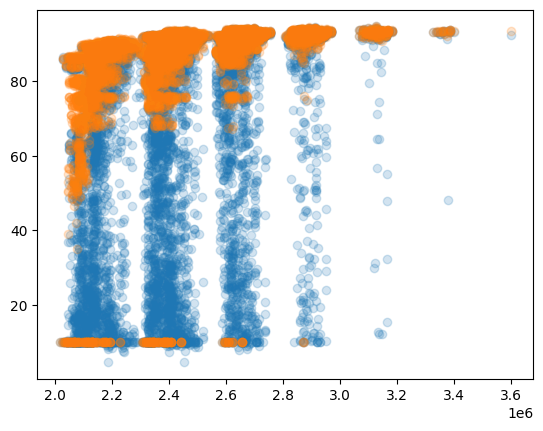

In [36]:
plt.scatter(df_merged["total_size"], df_merged["esp_acc"], alpha = 0.2)
plt.scatter(df_merged["total_size"], df_merged["fp32_acc"], alpha = 0.2)
plt.show()

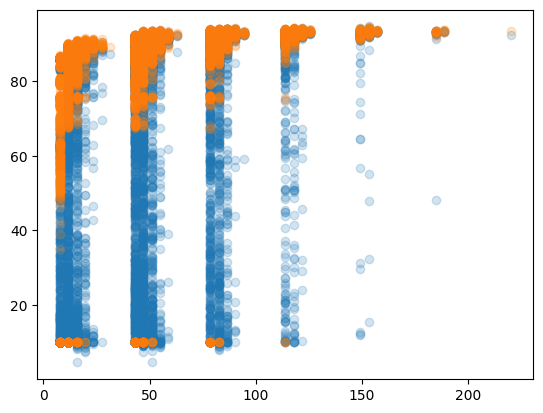

In [37]:
plt.scatter(df_merged["flop"], df_merged["esp_acc"], alpha = 0.2)
plt.scatter(df_merged["flop"], df_merged["fp32_acc"], alpha = 0.2)
plt.show()

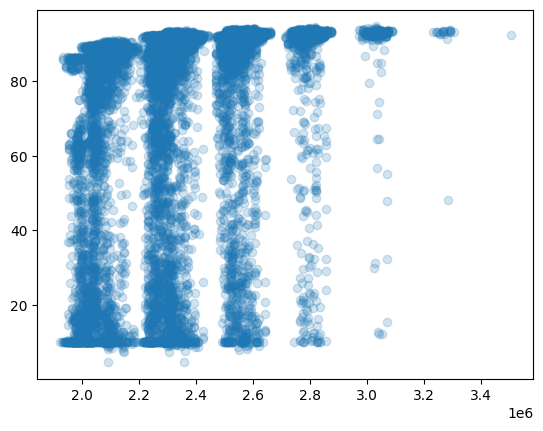

In [38]:
plt.scatter(df_merged["Unnamed: 28"], df_merged["esp_acc"], alpha = 0.2)
plt.show()

In [24]:
df_merged["Unnamed: 28"].value_counts()

Unnamed: 28
2314970.0    7
2340762.0    7
2306378.0    6
2360330.0    6
2356026.0    6
            ..
2291242.0    1
2028586.0    1
2358106.0    1
1998122.0    1
2798890.0    1
Name: count, Length: 10695, dtype: int64